In [40]:
import pandas as pd

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

In [42]:
df=pd.read_csv('job_change.csv');

In [43]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,29725,city_40,782.00,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,47,stay
1,666,city_162,775.25,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,8,stay
2,28806,city_160,890.00,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,24,stay
3,402,city_46,771.50,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,18,switch
4,27107,city_103,890.00,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,46,switch
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10663,251,city_103,890.00,Male,Has relevent experience,no_enrollment,Masters,STEM,9,50-99,Pvt Ltd,36,switch
10664,32313,city_160,890.00,Female,Has relevent experience,no_enrollment,Graduate,STEM,10,100-500,Public Sector,23,stay
10665,29754,city_103,890.00,Female,Has relevent experience,no_enrollment,Graduate,Humanities,7,10/49,Funded Startup,25,stay
10666,24576,city_103,890.00,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,44,stay


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             10668 non-null  int64  
 1   city                    10668 non-null  object 
 2   city_development_index  10668 non-null  float64
 3   gender                  10668 non-null  object 
 4   relevent_experience     10668 non-null  object 
 5   enrolled_university     10668 non-null  object 
 6   education_level         10569 non-null  object 
 7   major_discipline        9740 non-null   object 
 8   experience              10657 non-null  object 
 9   company_size            10252 non-null  object 
 10  company_type            10135 non-null  object 
 11  training_hours          10668 non-null  int64  
 12  target                  10668 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 1.1+ MB


In [45]:
cat_cols=df.select_dtypes(include='object').columns

In [49]:
# df["city"] = df["city"].str.findall(r"\d+").str.join("") or
df['city']=df['city'].str.split('_').str[1]

In [50]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,29725,40,782.00,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,47,stay
1,666,162,775.25,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,8,stay
2,28806,160,890.00,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,24,stay
3,402,46,771.50,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,18,switch
4,27107,103,890.00,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,46,switch
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10663,251,103,890.00,Male,Has relevent experience,no_enrollment,Masters,STEM,9,50-99,Pvt Ltd,36,switch
10664,32313,160,890.00,Female,Has relevent experience,no_enrollment,Graduate,STEM,10,100-500,Public Sector,23,stay
10665,29754,103,890.00,Female,Has relevent experience,no_enrollment,Graduate,Humanities,7,10/49,Funded Startup,25,stay
10666,24576,103,890.00,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,44,stay


In [51]:
cat_cols

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'target'],
      dtype='object')

In [52]:
#inside each cat col, what is the freq of each category

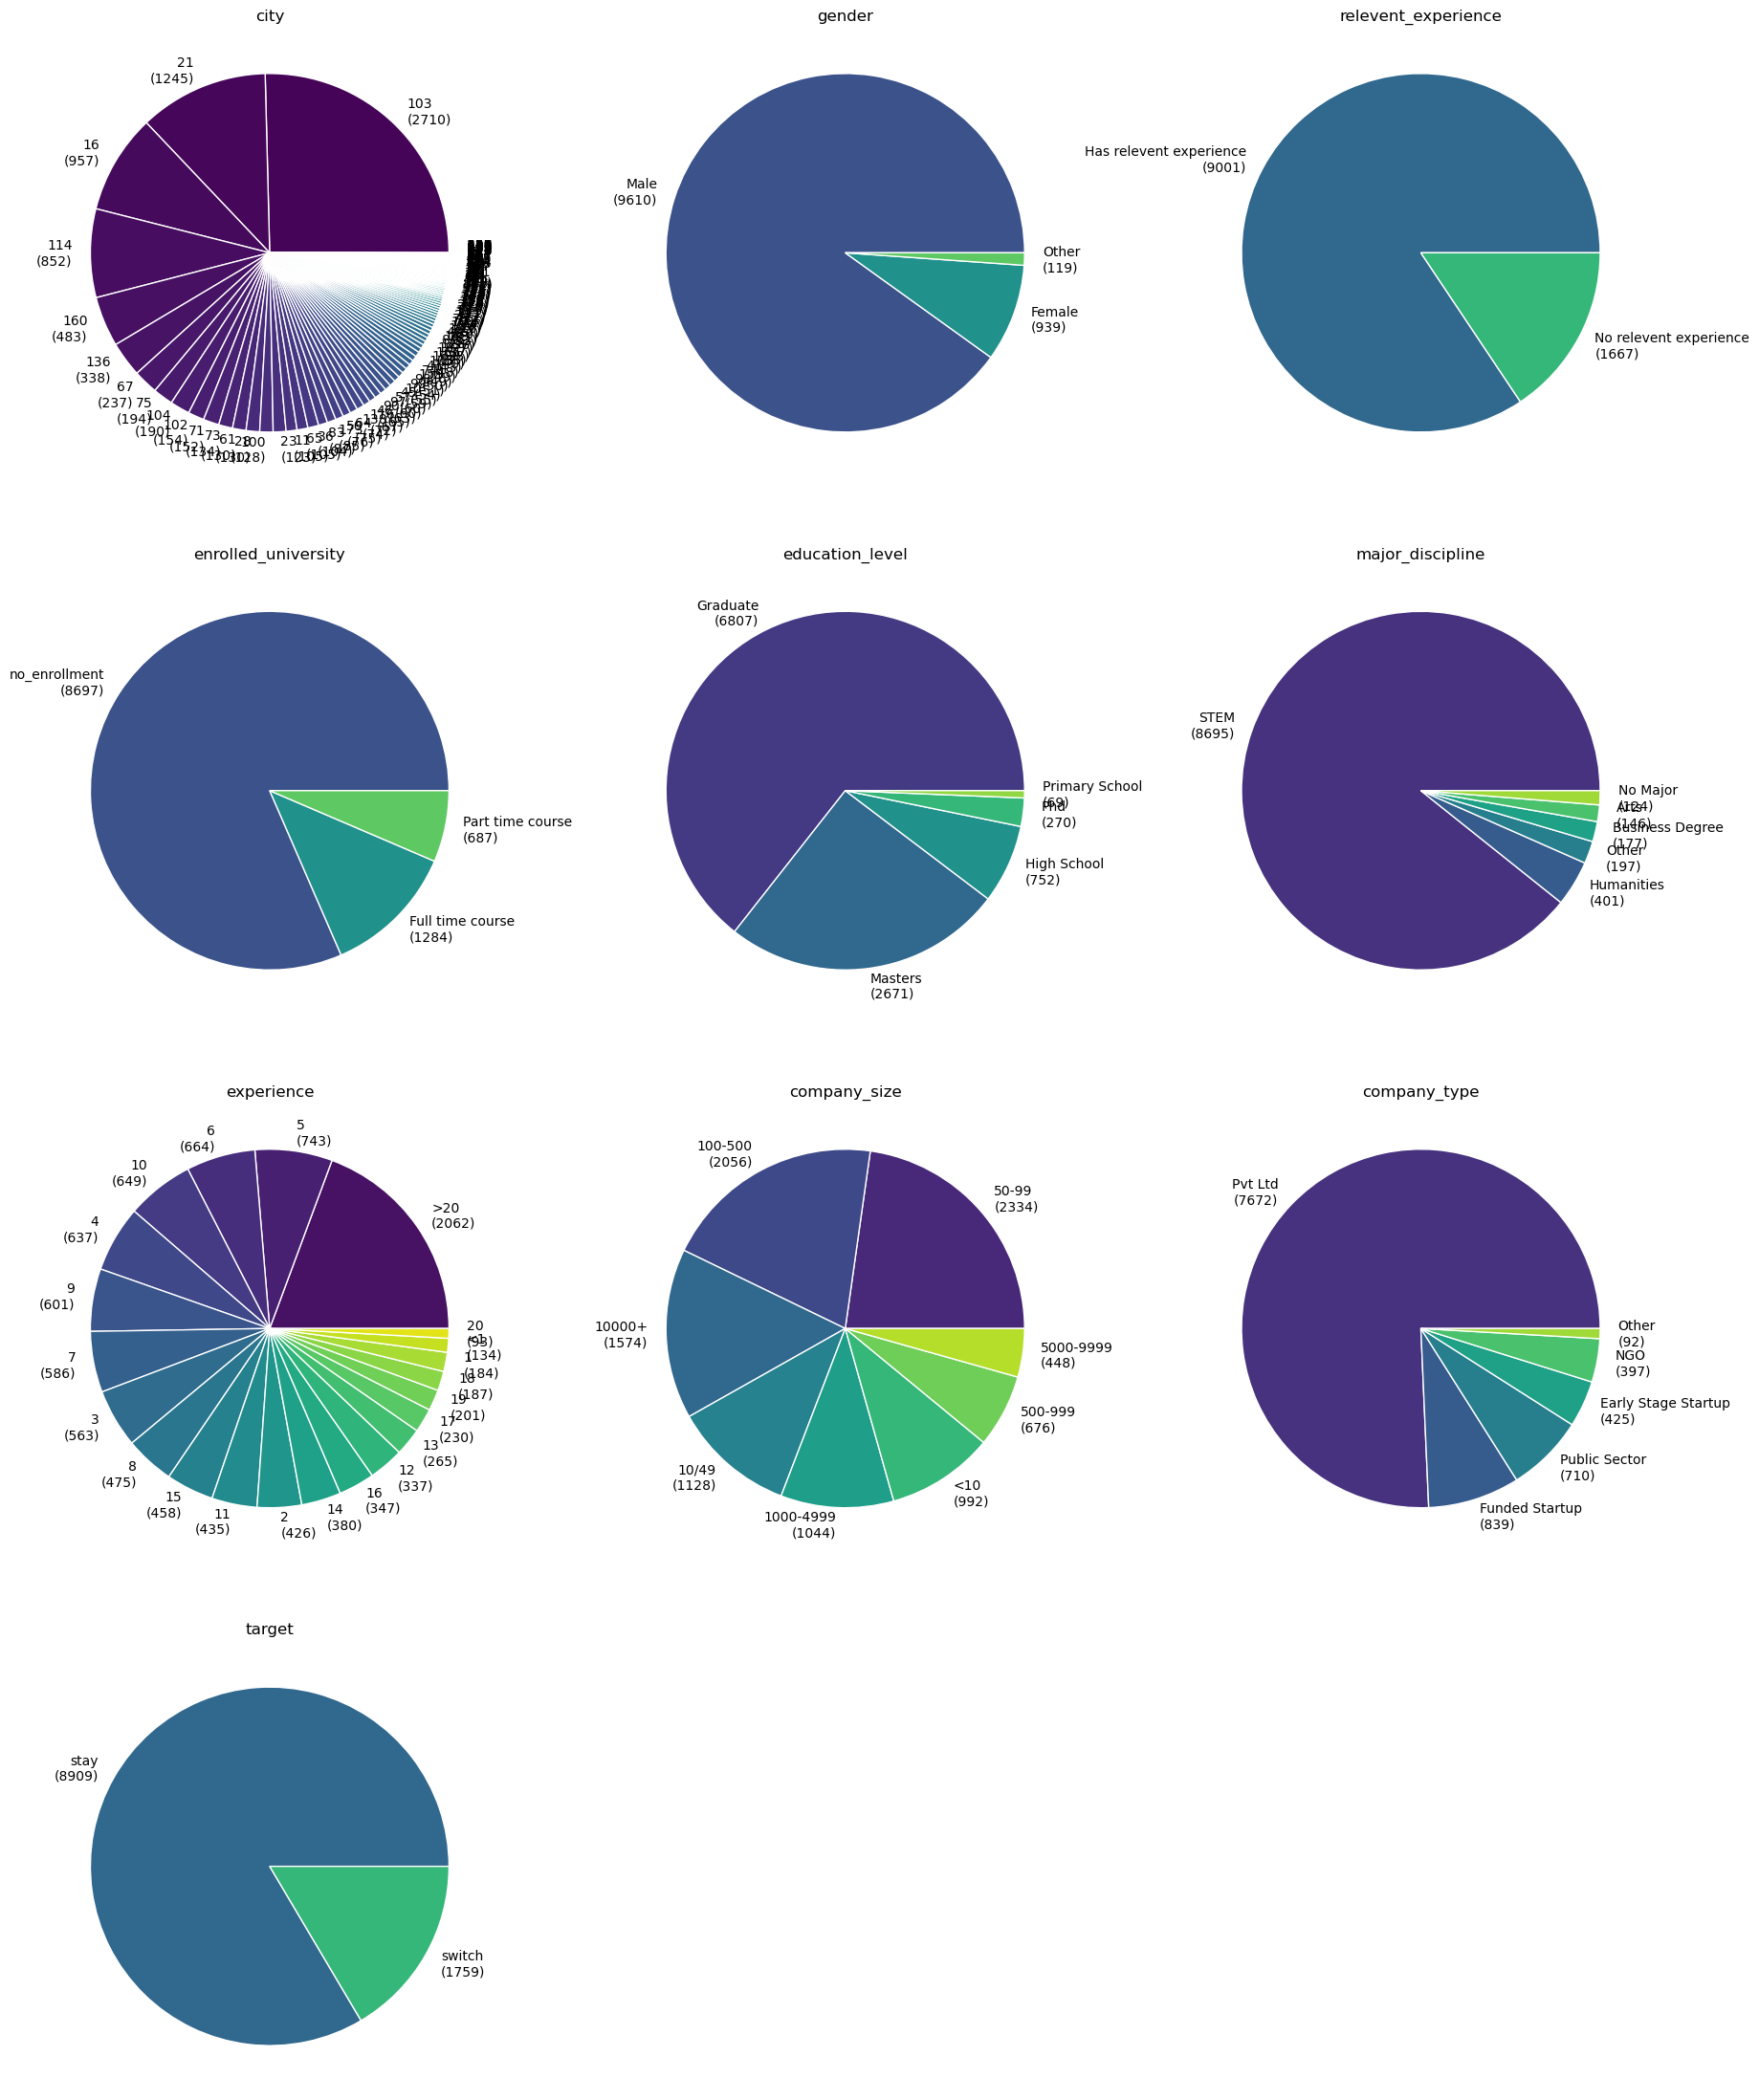

In [74]:
import math
fig,axes=plt.subplots(math.ceil(len(cat_cols)/3),3,figsize=(22,28))
axes=axes.flatten()
for i,col in enumerate(cat_cols):
    count=df[col].value_counts()
    colors=sns.color_palette('viridis',len(count))
    axes[i].pie(count.values,labels=[f'{cat}\n({freq})'for cat,freq in count.items()],
               colors=colors,wedgeprops={'edgecolor':'white'})
    axes[i].set_title(col)
axes[10].set_visible(False)
axes[11].set_visible(False)
plt.show()
fig.savefig('Job Change.svg',format='svg',dpi=300)

In [72]:
len(df['city'].unique())

118

In [81]:
freq=df.groupby(['city','target']).size().unstack()
freq.index=freq.index.astype(int)
freq.sort_index(inplace=True)

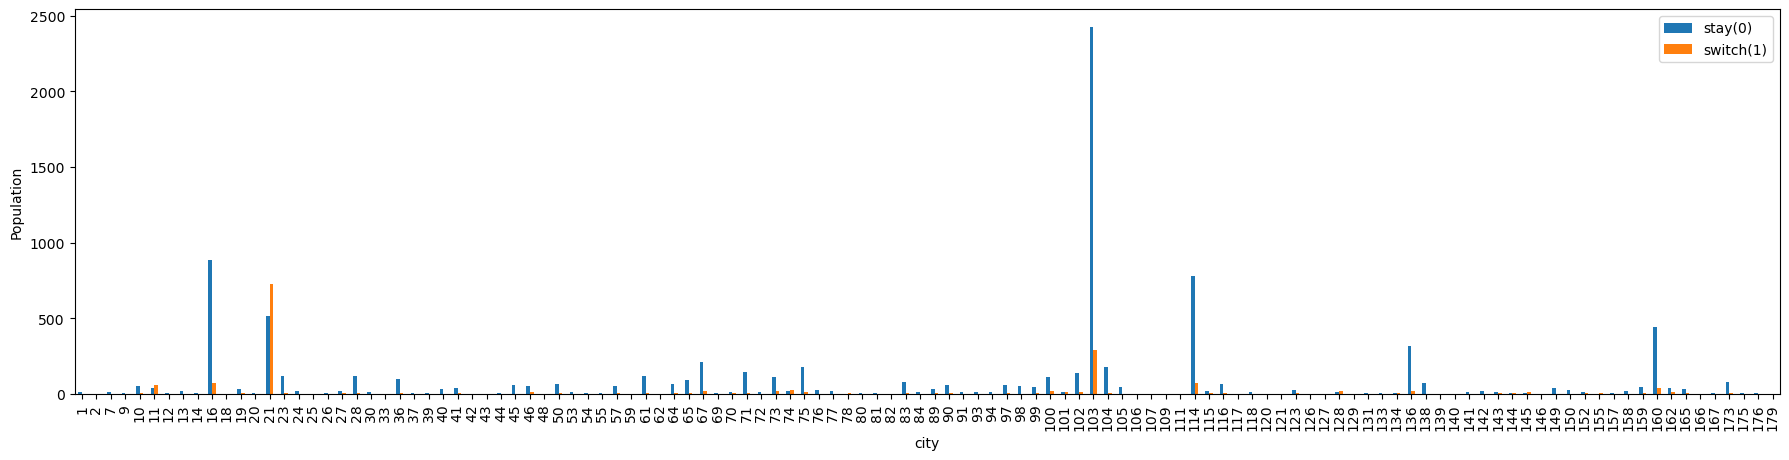

In [83]:
freq.plot(kind='bar',figsize=(22,5))
plt.xlabel('city')
plt.ylabel('Population')
plt.legend(['stay(0)','switch(1)'])

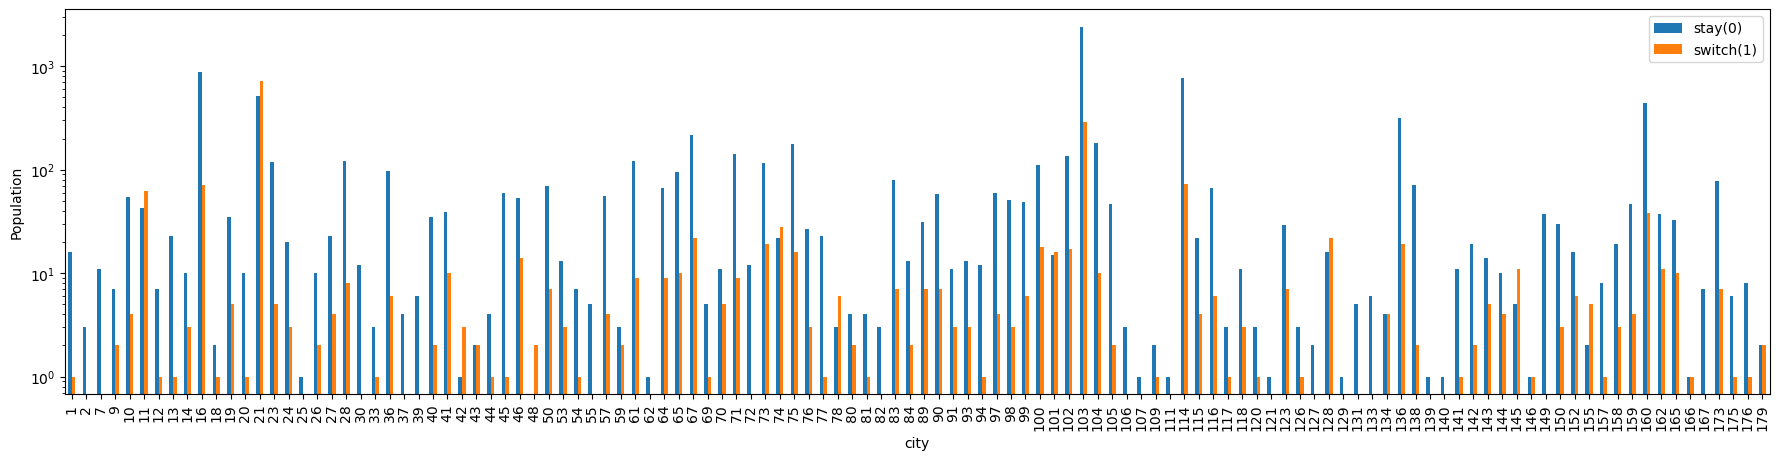

In [84]:
freq.plot(kind='bar',figsize=(22,5))
plt.yscale('log')
plt.xlabel('city')
plt.ylabel('Population')
plt.legend(['stay(0)','switch(1)'])

In [85]:
df['experience'].unique()

array(['15', '>20', '5', '13', '7', '16', '11', '<1', '18', '19', '12',
       '10', '1', '4', '9', '2', '6', '14', '3', '8', '17', '20', nan],
      dtype=object)

In [92]:
freq1=df[~df['experience'].isin(['<1,>20'])].groupby(['experience','target']).size().unstack(fill_value=0)

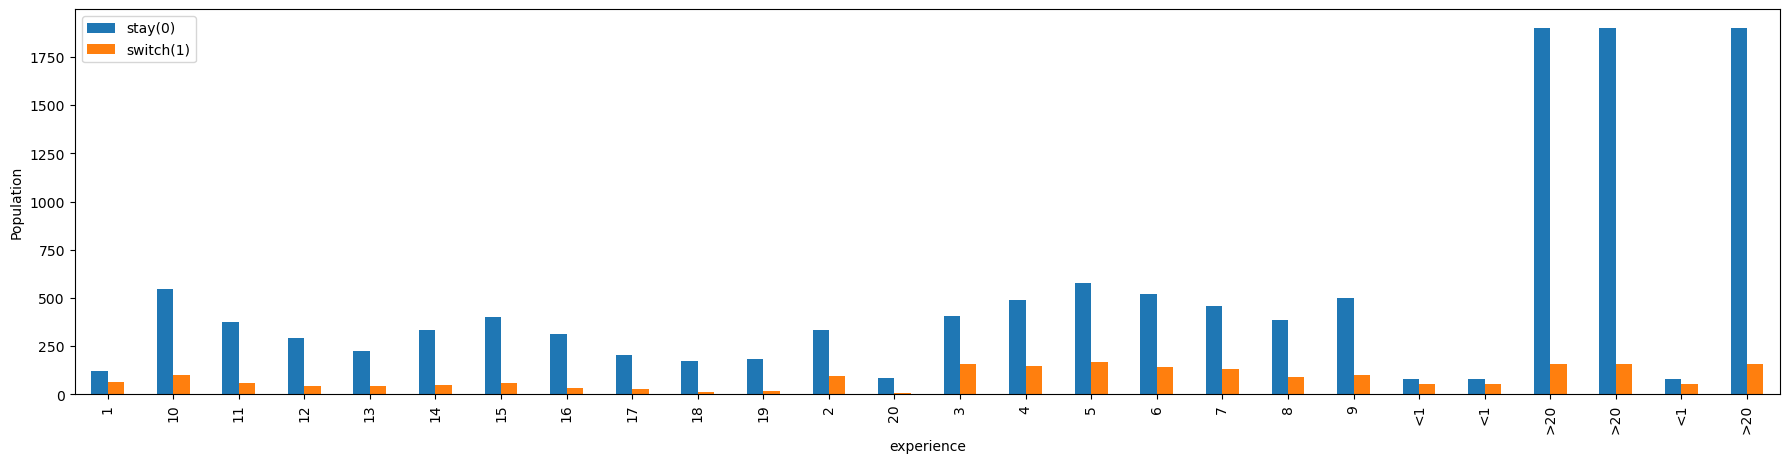

In [99]:
freq1.sort_index(inplace=True)
freq1.index=freq1.index.astype(str)
temp=df[df['experience'].isin(['<1','>20'])].groupby(['experience','target']).size().unstack(fill_value=0)
freq1=pd.concat([freq1,temp],axis=0)

freq1.plot(kind='bar',figsize=(22,5))
plt.xlabel('experience')
plt.ylabel('Population')
plt.legend(['stay(0)','switch(1)'])
plt.show()

In [95]:
exp_order=['<1']+list(freq1.index)+['>20']
df_copy=df.copy()
df_copy.shape

(10668, 13)

In [98]:
ohe_city=OneHotEncoder(drop='first',max_categories=86,handle_unknown='infrequent_if_exist')
city_encoded=ohe_city.fit_transform(df[['city']]).toarray()
print(city_encoded.shape)
city_df=pd.DataFrame(city_encoded,columns=ohe_city.get_feature_names_out())
df_copy.drop(columns=['city'],inplace=True)
df_copy=pd.concat([df_copy,city_df],axis=1)
df_copy.head()

(10668, 85)


,enrollee_id,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,...,city_89,city_9,city_90,city_91,city_93,city_94,city_97,city_98,city_99,city_infrequent_sklearn
0,29725,782.00,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,666,775.25,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,28806,890.00,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,402,771.50,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,27107,890.00,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
